# Phase 3 (Improved): CRNN Model Training for Hindi HTR

**Architecture Upgrades over baseline:**
- ResNet backbone with integrated Squeeze-and-Excitation (SE) blocks (replaces VGG-7)
- 3-layer BiLSTM with 512 hidden units (up from 2×256)
- Beam-search decoding (beam width 10)
- Cosine-annealing LR with linear warmup
- Enhanced augmentation (perspective, brightness/contrast jitter)
- Label-smoothing regularisation for CTC
- Gradient accumulation support
- Optional WeightedRandomSampler for rare-character oversampling
- Test-Time Augmentation (TTA) evaluation

**Input:** Phase 2 artifacts (char_vocab.json, preprocess_config.json) + 200k dataset
**Output:** Trained model checkpoint + training curves + test CER/WER metrics
**Platform:** Kaggle notebook with T4 GPU


## 1. Install Dependencies + Devanagari Font

-rw-r--r-- 1 root root 647144 May  9 09:23 /tmp/NotoSansDevanagari.ttf


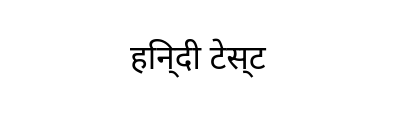

Font loaded successfully!


In [16]:
!pip install -q editdistance tqdm torchinfo

# Download Devanagari font for matplotlib
!wget -q https://github.com/google/fonts/raw/main/ofl/notosansdevanagari/NotoSansDevanagari%5Bwdth%2Cwght%5D.ttf -O /tmp/NotoSansDevanagari.ttf
!ls -la /tmp/NotoSansDevanagari.ttf

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fm.fontManager.addfont('/tmp/NotoSansDevanagari.ttf')
plt.rcParams['font.family'] = 'Noto Sans Devanagari'
plt.rcParams['figure.dpi'] = 120

# Quick test
fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, 'हिन्दी टेस्ट', fontsize=20, ha='center', va='center')
ax.axis('off')
plt.show()
print('Font loaded successfully!')


## 2. Imports and Device Setup

In [17]:
import os, json, time, random, math, unicodedata, warnings
from pathlib import Path
from io import BytesIO
from collections import Counter
from typing import Any, List, Tuple, Optional

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import editdistance
from tqdm.auto import tqdm
from torchinfo import summary

warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
import matplotlib.font_manager as fm

# ── Reproducibility ──
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = False   # keep True only for exact repro
    torch.backends.cudnn.benchmark = True         # faster conv selection

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

RESULTS  = Path('/kaggle/working/results');  RESULTS.mkdir(exist_ok=True)
CKPT_DIR = Path('/kaggle/working/checkpoints'); CKPT_DIR.mkdir(exist_ok=True)

# Register Devanagari font
FONT_PATH = Path('/tmp/NotoSansDevanagari.ttf')
if FONT_PATH.exists():
    fm.fontManager.addfont(str(FONT_PATH))
    DEVA_FONT = fm.FontProperties(fname=str(FONT_PATH))
    plt.rcParams['font.family'] = DEVA_FONT.get_name()
    print(f'Devanagari font loaded: {DEVA_FONT.get_name()}')
else:
    DEVA_FONT = None
    print('WARNING: Devanagari font not found.')


Device: cuda
GPU   : Tesla T4
Devanagari font loaded: Noto Sans Devanagari


## 3. Load Phase 2 Artifacts (200k dataset)

In [18]:
# Phase 2 artifacts for the 200k dataset
PHASE2_DIR = Path('/kaggle/input/datasets/nehamalik10/hindi-htr-phase2-artifacts-improved')

vocab_path  = PHASE2_DIR / 'char_vocab.json'
config_path = PHASE2_DIR / 'preprocess_config.json'

if not vocab_path.exists():
    raise FileNotFoundError(
        f"Phase 2 vocab not found at {vocab_path}\n"
        f"Upload char_vocab.json and preprocess_config.json as a Kaggle dataset."
    )

with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab_data = json.load(f)
with open(config_path, 'r') as f:
    config = json.load(f)

char_to_idx = vocab_data['char_to_idx']
idx_to_char = {int(k): v for k, v in vocab_data['idx_to_char'].items()}
BLANK_IDX   = vocab_data['blank_idx']      # 0
UNK_IDX     = vocab_data['unk_idx']         # 137
PAD_IDX     = vocab_data['pad_idx']         # 138
NUM_CLASSES = len(char_to_idx)              # 139

IMG_H = config['image_height']   # 32
IMG_W = config['image_width']    # 128

print(f'Vocab : {NUM_CLASSES} classes | Image: {IMG_H}×{IMG_W}')
print(f'BLANK={BLANK_IDX}  UNK={UNK_IDX}  PAD={PAD_IDX}')


Vocab : 139 classes | Image: 32×128
BLANK=0  UNK=137  PAD=138


## 4. Load Dataset (200k)

In [19]:
BASE = '/kaggle/input/datasets/nehamalik10/hindi-ocr-new-dataset'

train_df = pd.read_parquet(os.path.join(BASE, 'train.parquet'))
val_df   = pd.read_parquet(os.path.join(BASE, 'val.parquet'))
test_df  = pd.read_parquet(os.path.join(BASE, 'test.parquet'))

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')


Train: 150,000 | Val: 20,000 | Test: 30,000


## 5. Verify Vocab Integrity

In [20]:
IMG_COL   = "image"
LABEL_COL = "text"

test_word   = train_df[LABEL_COL].iloc[0]
test_norm   = " ".join(unicodedata.normalize("NFC", str(test_word)).strip().split())
test_enc    = [char_to_idx.get(ch, UNK_IDX) for ch in test_norm]
test_dec    = ''.join([idx_to_char.get(i, '') for i in test_enc])

print('Vocab roundtrip test:')
print(f'  Original : {test_norm}')
print(f'  Encoded  : {test_enc}')
print(f'  Decoded  : {test_dec}')
clean = test_dec.replace('<BLANK>', '').replace('<UNK>', '').replace('<PAD>', '')
assert test_norm == clean, "CRITICAL: roundtrip failed!"
print('  Status   : PASSED ✓')


Vocab roundtrip test:
  Original : के
  Encoded  : [58, 106]
  Decoded  : के
  Status   : PASSED ✓


## 6. Preprocessing & Advanced Augmentation

**Enhancements over baseline:**
- Higher augmentation probabilities
- NEW: Perspective transform (simulates camera-captured documents)
- NEW: Brightness / contrast jitter (simulates lighting variation)


In [21]:
# ═══════════════════════════════════════════════════
#  Configuration (must match Phase 2)
# ═══════════════════════════════════════════════════
IMG_HEIGHT, IMG_WIDTH = IMG_H, IMG_W
BINARIZATION_MODE  = config.get('binarization_mode', 'otsu')
SKIP_BINARIZATION  = config.get('skip_binarization', False)
INVERT_IMAGE       = config.get('invert_image', False)
KEEP_ASPECT_RATIO  = config.get('keep_aspect_ratio', True)
TIGHT_CROP_PAD     = config.get('tight_crop_pad', 2)

# ── Augmentation probabilities (tuned up) ──
AUG_ROTATE_PROB          = 0.60
AUG_ELASTIC_PROB         = 0.50
AUG_NOISE_PROB           = 0.50
AUG_ERODE_DILATE_PROB    = 0.25
AUG_SHEAR_PROB           = 0.55
AUG_CUTOUT_PROB          = 0.35
AUG_PERSPECTIVE_PROB     = 0.30   # NEW
AUG_BRIGHTNESS_PROB      = 0.40   # NEW

# ═══════════════════════════════════════════════════
#  Image loading helpers
# ═══════════════════════════════════════════════════
def row_to_image(row, image_col=IMG_COL):
    value = row[image_col]
    if isinstance(value, Image.Image):
        return value.convert("RGB")
    if isinstance(value, dict):
        if value.get("bytes") is not None:
            return Image.open(BytesIO(value["bytes"])).convert("RGB")
        if value.get("path") is not None:
            return Image.open(value["path"]).convert("RGB")
    if isinstance(value, (bytes, bytearray)):
        return Image.open(BytesIO(value)).convert("RGB")
    if isinstance(value, np.ndarray):
        return Image.fromarray(value).convert("RGB")
    if isinstance(value, (str, Path)):
        return Image.open(value).convert("RGB")
    raise TypeError(f"Unsupported image type: {type(value)}")

# ═══════════════════════════════════════════════════
#  Core preprocessing pipeline (identical to Phase 2)
# ═══════════════════════════════════════════════════
def pil_to_gray_np(image):
    return np.array(image.convert("L"))

def autocontrast_gray(gray):
    return np.array(ImageOps.autocontrast(Image.fromarray(gray)))

def denoise_gray(gray):
    return cv2.medianBlur(gray, 3)

def binarize_gray(gray, mode=BINARIZATION_MODE):
    if mode == "otsu":
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    elif mode == "adaptive":
        binary = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 11)
    else:
        raise ValueError(f"Unknown binarization mode: {mode}")
    return binary

def ensure_black_text(img):
    if INVERT_IMAGE or np.mean(img < 128) > 0.55:
        return 255 - img
    return img

def deskew_image(img):
    coords = np.column_stack(np.where(img < 128))
    if len(coords) < 10:
        return img
    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle
    if abs(angle) > 8:
        return img
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderValue=255)

def tight_crop(img, pad=TIGHT_CROP_PAD):
    coords = np.column_stack(np.where(img < 200))
    if len(coords) == 0:
        return img
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    y0, x0 = max(0, y0 - pad), max(0, x0 - pad)
    y1 = min(img.shape[0], y1 + pad + 1)
    x1 = min(img.shape[1], x1 + pad + 1)
    cropped = img[y0:y1, x0:x1]
    return cropped if cropped.size > 0 else img

def resize_with_padding(img, target_h=IMG_HEIGHT, target_w=IMG_WIDTH):
    h, w = img.shape
    if h <= 0 or w <= 0:
        return np.full((target_h, target_w), 255, dtype=np.uint8)
    if KEEP_ASPECT_RATIO:
        scale = min(target_w / w, target_h / h)
        new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
        resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
        canvas = np.full((target_h, target_w), 255, dtype=np.uint8)
        x0, y0 = (target_w - new_w) // 2, (target_h - new_h) // 2
        canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
        return canvas
    return cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_AREA)

def normalize_image(image):
    return (image.astype(np.float32) / 255.0 - 0.5) / 0.5

def preprocess_image(image, return_steps=False):
    gray      = pil_to_gray_np(image)
    contrast  = autocontrast_gray(gray)
    denoised  = denoise_gray(contrast)
    deskewed  = deskew_image(denoised)
    cropped   = tight_crop(deskewed)
    if SKIP_BINARIZATION:
        processed = ensure_black_text(cropped)
    else:
        processed = ensure_black_text(binarize_gray(cropped))
    resized    = resize_with_padding(processed)
    normalized = normalize_image(resized)
    if return_steps:
        return {"resized": resized, "normalized": normalized}
    return normalized

def normalize_label(text):
    return " ".join(unicodedata.normalize("NFC", str(text)).strip().split())

def encode_label(label):
    return [char_to_idx.get(ch, UNK_IDX) for ch in normalize_label(label)]

# ═══════════════════════════════════════════════════
#  Augmentation functions
# ═══════════════════════════════════════════════════
def random_rotation(image, max_angle=5.0):
    angle = random.uniform(-max_angle, max_angle)
    h, w = image.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=255)

def elastic_distortion(image, alpha=7.0, sigma=4.0):
    h, w = image.shape
    dx = cv2.GaussianBlur(np.random.uniform(-1, 1, (h, w)).astype(np.float32), (0, 0), sigma) * alpha
    dy = cv2.GaussianBlur(np.random.uniform(-1, 1, (h, w)).astype(np.float32), (0, 0), sigma) * alpha
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    return cv2.remap(image, (x + dx).astype(np.float32), (y + dy).astype(np.float32),
                     interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=255)

def add_noise(image, std=10.0):
    noise = np.random.normal(0, std, image.shape).astype(np.float32)
    return np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def random_erode_dilate(image):
    kernel = np.ones((2, 2), np.uint8)
    return cv2.erode(image, kernel, 1) if random.random() < 0.5 else cv2.dilate(image, kernel, 1)

def random_shear(image, max_shear_deg=12.0):
    h, w = image.shape
    s = np.radians(random.uniform(-max_shear_deg, max_shear_deg))
    M = np.array([[1, s, -s * h / 2], [0, 1, 0]], dtype=np.float32)
    return cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=255)

def random_cutout(image, num_patches=3, patch_size=4):
    result = image.copy()
    h, w = result.shape
    for _ in range(random.randint(1, num_patches)):
        y = random.randint(0, max(0, h - patch_size))
        x = random.randint(0, max(0, w - patch_size))
        result[y:y + patch_size, x:x + patch_size] = 255
    return result

# ── NEW: Perspective transform ──
def random_perspective(image, scale=0.05):
    h, w = image.shape
    margin_x, margin_y = int(w * scale), int(h * scale)
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    dst = np.float32([
        [random.randint(0, margin_x), random.randint(0, margin_y)],
        [w - random.randint(0, margin_x), random.randint(0, margin_y)],
        [w - random.randint(0, margin_x), h - random.randint(0, margin_y)],
        [random.randint(0, margin_x), h - random.randint(0, margin_y)]
    ])
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(image, M, (w, h), borderValue=255)

# ── NEW: Brightness / contrast jitter ──
def random_brightness_contrast(image, brightness_range=0.3, contrast_range=0.3):
    img = image.astype(np.float32)
    alpha = 1.0 + random.uniform(-contrast_range, contrast_range)   # contrast
    beta  = random.uniform(-brightness_range, brightness_range) * 255  # brightness
    return np.clip(alpha * img + beta, 0, 255).astype(np.uint8)

# ── Combined augmentation ──
def augment_image(image):
    aug = image.copy()
    if random.random() < AUG_ROTATE_PROB:          aug = random_rotation(aug)
    if random.random() < AUG_ELASTIC_PROB:         aug = elastic_distortion(aug)
    if random.random() < AUG_PERSPECTIVE_PROB:     aug = random_perspective(aug)
    if random.random() < AUG_BRIGHTNESS_PROB:      aug = random_brightness_contrast(aug)
    if random.random() < AUG_NOISE_PROB:           aug = add_noise(aug)
    if random.random() < AUG_ERODE_DILATE_PROB:    aug = random_erode_dilate(aug)
    if random.random() < AUG_SHEAR_PROB:           aug = random_shear(aug)
    if random.random() < AUG_CUTOUT_PROB:          aug = random_cutout(aug)
    return aug

print("All preprocessing and augmentation functions loaded. ✓")


All preprocessing and augmentation functions loaded. ✓


## 7. PyTorch Dataset & WeightedRandomSampler

A toggle `ENABLE_WEIGHTED_SAMPLING` enables rare-character oversampling.
When enabled, samples containing rare characters are drawn more frequently.


In [22]:
class HindiHTRDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        text = normalize_label(str(row[LABEL_COL]))
        try:
            pil_img = row_to_image(row)
        except Exception:
            return torch.zeros(1, IMG_H, IMG_W), torch.IntTensor([BLANK_IDX]), 1

        steps   = preprocess_image(pil_img, return_steps=True)
        resized = steps["resized"]
        if self.augment:
            resized = augment_image(resized)
        normalized = normalize_image(resized)
        img   = torch.FloatTensor(normalized).unsqueeze(0)       # (1, 32, 128)
        label = [char_to_idx.get(ch, UNK_IDX) for ch in text]
        return img, torch.IntTensor(label), len(label)


# ── WeightedRandomSampler helper ──
def compute_sample_weights(df, char_to_idx, unk_idx):
    """Inverse-frequency weighting so rare characters are sampled more."""
    char_counts = Counter()
    for text in df[LABEL_COL]:
        for ch in normalize_label(str(text)):
            char_counts[char_to_idx.get(ch, unk_idx)] += 1
    total = sum(char_counts.values())
    n_classes = max(len(char_counts), 1)
    char_w = {idx: total / (cnt * n_classes) for idx, cnt in char_counts.items()}

    weights = []
    for text in df[LABEL_COL]:
        chars = normalize_label(str(text))
        if not chars:
            weights.append(1.0)
            continue
        weights.append(sum(char_w.get(char_to_idx.get(c, unk_idx), 1.0) for c in chars) / len(chars))
    return torch.DoubleTensor(weights)

print("Dataset class and sampler helper ready. ✓")


Dataset class and sampler helper ready. ✓


## 8. Collate Function & DataLoaders

In [23]:
def collate_fn(batch):
    imgs, labs, lens = zip(*batch)
    return torch.stack(imgs), torch.cat(labs), torch.IntTensor(list(lens))

# ═══════════════════════════════════════════════════
#  Hyper-parameters
# ═══════════════════════════════════════════════════
BS = 64                          # reduce to 32 if OOM
ENABLE_WEIGHTED_SAMPLING = False # toggle rare-char oversampling

train_dataset = HindiHTRDataset(train_df, augment=True)

if ENABLE_WEIGHTED_SAMPLING:
    print("Computing sample weights for WeightedRandomSampler …")
    sample_weights = compute_sample_weights(train_df, char_to_idx, UNK_IDX)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(train_dataset, batch_size=BS, sampler=sampler,
                              collate_fn=collate_fn, num_workers=2, pin_memory=True)
    print(f"WeightedRandomSampler enabled ({len(sample_weights):,} weights)")
else:
    train_loader = DataLoader(train_dataset, batch_size=BS, shuffle=True,
                              collate_fn=collate_fn, num_workers=2, pin_memory=True)

val_loader  = DataLoader(HindiHTRDataset(val_df,  augment=False), batch_size=BS,
                          shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader = DataLoader(HindiHTRDataset(test_df, augment=False), batch_size=BS,
                          shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)

imgs, labels, lens = next(iter(train_loader))
print(f'Batch images : {imgs.shape}')
print(f'Labels       : {labels.shape}')
print(f'Lengths      : {lens.shape}')


Batch images : torch.Size([64, 1, 32, 128])
Labels       : torch.Size([259])
Lengths      : torch.Size([64])


## 9. Improved CRNN: ResNet Backbone with Integrated SE Blocks

**Key differences from baseline VGG-7:**
- Each residual block has a skip connection → solves vanishing gradients
- SE (Squeeze-and-Excitation) module *inside* each block → channel attention
- Deeper feature extraction (14 conv layers vs 7)
- 3-layer BiLSTM with 512 hidden units


In [24]:
# ═══════════════════════════════════════════════════
#  Squeeze-and-Excitation Block
# ═══════════════════════════════════════════════════
class SEBlock(nn.Module):
    """Channel attention: squeeze spatial → excite channels."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w


# ═══════════════════════════════════════════════════
#  Residual Block with integrated SE
# ═══════════════════════════════════════════════════
class ResidualSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, se_reduction=16):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.se    = SEBlock(out_ch, se_reduction)
        self.relu  = nn.ReLU(inplace=True)

        # 1×1 projection shortcut when dimensions change
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)            # channel attention
        out = self.relu(out + residual)
        return out


# ═══════════════════════════════════════════════════
#  Improved CRNN Model
# ═══════════════════════════════════════════════════
class ImprovedCRNN(nn.Module):
    """
    ResNet-SE backbone  +  3-layer BiLSTM  +  CTC head
    Input : (B, 1, 32, 128)
    Output: (T=32, B, num_classes)  — log-softmax for CTC
    """
    def __init__(self, num_classes, hidden_size=512, num_layers=3, dropout=0.4):
        super().__init__()

        # ── CNN backbone ──
        # (B,1,32,128) → (B,512,1,32)
        self.backbone = nn.Sequential(
            # Stem
            nn.Conv2d(1, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),

            # Stage 1: 64→64, pool 2×2 → 16×64
            ResidualSEBlock(64, 64),
            nn.MaxPool2d(2, 2),

            # Stage 2: 64→128, pool 2×2 → 8×32
            ResidualSEBlock(64, 128),
            nn.MaxPool2d(2, 2),

            # Stage 3: 128→256, pool (2,1) → 4×32
            ResidualSEBlock(128, 256),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Dropout2d(dropout * 0.5),

            # Stage 4: 256→512, pool (2,1) → 2×32
            ResidualSEBlock(256, 512),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Dropout2d(dropout * 0.5),

            # Collapse height: 2→1
            nn.Conv2d(512, 512, (2, 1), bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
        )

        # ── BiLSTM ──
        self.rnn = nn.LSTM(
            input_size=512, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            bidirectional=True, dropout=dropout
        )

        # ── Classification head ──
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        conv = self.backbone(x)          # (B, 512, 1, 32)
        conv = conv.squeeze(2)           # (B, 512, 32)
        conv = conv.permute(0, 2, 1)     # (B, 32, 512)
        rnn_out, _ = self.rnn(conv)      # (B, 32, 1024)
        out = self.fc(rnn_out)           # (B, 32, C)
        out = out.permute(1, 0, 2)       # (T=32, B, C)
        return F.log_softmax(out, dim=2)

print("Model classes defined. ✓")


Model classes defined. ✓


## 10. Model Instantiation & Verification

In [25]:
HIDDEN_SIZE = 512
NUM_LSTM_LAYERS = 3
DROPOUT = 0.4

model = ImprovedCRNN(NUM_CLASSES, HIDDEN_SIZE, NUM_LSTM_LAYERS, DROPOUT).to(device)

# Shape check
with torch.no_grad():
    dummy = torch.zeros(2, 1, IMG_H, IMG_W, device=device)
    out = model(dummy)
    print(f'Output shape: {out.shape}  (T={out.size(0)}, B={out.size(1)}, C={out.size(2)})')

total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters  : {total:,} total, {train_:,} trainable')
summary(model, input_size=(1, 1, IMG_H, IMG_W))


Output shape: torch.Size([32, 2, 139])  (T=32, B=2, C=139)
Parameters  : 22,410,571 total, 22,410,571 trainable


Layer (type:depth-idx)                        Output Shape              Param #
ImprovedCRNN                                  [32, 1, 139]              --
├─Sequential: 1-1                             [1, 512, 1, 32]           --
│    └─Conv2d: 2-1                            [1, 64, 32, 128]          576
│    └─BatchNorm2d: 2-2                       [1, 64, 32, 128]          128
│    └─ReLU: 2-3                              [1, 64, 32, 128]          --
│    └─ResidualSEBlock: 2-4                   [1, 64, 32, 128]          --
│    │    └─Sequential: 3-1                   [1, 64, 32, 128]          --
│    │    └─Conv2d: 3-2                       [1, 64, 32, 128]          36,864
│    │    └─BatchNorm2d: 3-3                  [1, 64, 32, 128]          128
│    │    └─ReLU: 3-4                         [1, 64, 32, 128]          --
│    │    └─Conv2d: 3-5                       [1, 64, 32, 128]          36,864
│    │    └─BatchNorm2d: 3-6                  [1, 64, 32, 128]          128
│    │  

## 11. CTC Greedy Decoder

In [26]:
def greedy_decode(log_probs):
    """Decode a single (T, C) log-prob matrix with CTC greedy rules."""
    indices = torch.argmax(log_probs, dim=1).cpu().numpy()
    result, prev = [], BLANK_IDX
    for idx in indices:
        if idx != BLANK_IDX and idx != prev:
            result.append(idx)
        prev = idx
    return ''.join(idx_to_char.get(i, '') for i in result)


def greedy_decode_batch(log_probs):
    T, B, C = log_probs.shape
    return [greedy_decode(log_probs[:, i, :]) for i in range(B)]

print("Greedy decoder ready. ✓")


Greedy decoder ready. ✓


## 12. Beam-Search Decoder (CTC Prefix Beam Search)

> **Trade-off note:** Larger beam width → better accuracy but slower.
> We use **beam_width=5** during validation (speed) and **beam_width=10** for final test evaluation.


In [27]:
def beam_search_decode(log_probs, beam_width=10, blank=BLANK_IDX):
    """
    CTC prefix beam search.
    log_probs : (T, C)  — log-softmax output
    Returns   : decoded string (best hypothesis)
    """
    T, C = log_probs.shape
    probs = log_probs.cpu().numpy()

    # Each entry: (prefix_tuple, (p_blank, p_non_blank))
    beams = {(): (0.0, float('-inf'))}      # log-probs

    for t in range(T):
        new_beams = {}

        for prefix, (pb, pnb) in beams.items():
            p_total = np.logaddexp(pb, pnb)

            for c in range(C):
                p_c = probs[t, c]
                if c == blank:
                    # extend with blank
                    key = prefix
                    new_pb = p_total + p_c
                    if key in new_beams:
                        old_pb, old_pnb = new_beams[key]
                        new_beams[key] = (np.logaddexp(old_pb, new_pb), old_pnb)
                    else:
                        new_beams[key] = (new_pb, float('-inf'))
                else:
                    # extend with character c
                    if len(prefix) > 0 and prefix[-1] == c:
                        # same char → only allowed after blank
                        key = prefix
                        new_pnb = pnb + p_c
                        if key in new_beams:
                            old_pb2, old_pnb2 = new_beams[key]
                            new_beams[key] = (old_pb2, np.logaddexp(old_pnb2, new_pnb))
                        else:
                            new_beams[key] = (float('-inf'), new_pnb)

                        # same char after blank → new char
                        key2 = prefix + (c,)
                        new_pnb2 = pb + p_c
                        if key2 in new_beams:
                            old_pb3, old_pnb3 = new_beams[key2]
                            new_beams[key2] = (old_pb3, np.logaddexp(old_pnb3, new_pnb2))
                        else:
                            new_beams[key2] = (float('-inf'), new_pnb2)
                    else:
                        key = prefix + (c,)
                        new_pnb = p_total + p_c
                        if key in new_beams:
                            old_pb4, old_pnb4 = new_beams[key]
                            new_beams[key] = (old_pb4, np.logaddexp(old_pnb4, new_pnb))
                        else:
                            new_beams[key] = (float('-inf'), new_pnb)

        # Prune to top-k beams
        scored = {k: np.logaddexp(pb, pnb) for k, (pb, pnb) in new_beams.items()}
        top_keys = sorted(scored, key=scored.get, reverse=True)[:beam_width]
        beams = {k: new_beams[k] for k in top_keys}

    # Best prefix
    best = max(beams, key=lambda k: np.logaddexp(*beams[k]))
    return ''.join(idx_to_char.get(i, '') for i in best)


def beam_search_decode_batch(log_probs, beam_width=10):
    T, B, C = log_probs.shape
    return [beam_search_decode(log_probs[:, i, :], beam_width) for i in range(B)]

print("Beam-search decoder ready. ✓")


Beam-search decoder ready. ✓


## 13. CER / WER Evaluation

In [28]:
def evaluate(model, loader, max_batches=None, use_beam=False, beam_width=5):
    """Evaluate model on a data loader. Returns (CER, WER)."""
    model.eval()
    total_ed, total_len, total_wer, count = 0, 0, 0.0, 0

    with torch.no_grad():
        for bi, (imgs, labels, label_lens) in enumerate(loader):
            if max_batches and bi >= max_batches:
                break
            out = model(imgs.to(device))          # (T, B, C)

            if use_beam:
                preds = beam_search_decode_batch(out, beam_width=beam_width)
            else:
                preds = greedy_decode_batch(out)

            offset = 0
            for i in range(imgs.size(0)):
                pred = preds[i]
                L = label_lens[i].item()
                gt = ''.join(idx_to_char.get(c, '') for c in labels[offset:offset + L].tolist())
                offset += L

                ed = editdistance.eval(pred, gt)
                total_ed  += ed
                total_len += max(len(gt), 1)
                total_wer += (0.0 if pred == gt else 1.0)
                count     += 1

    cer = total_ed / max(total_len, 1)
    wer = total_wer / max(count, 1)
    return cer, wer

print("Evaluation function ready. ✓")


Evaluation function ready. ✓


## 14. Training Setup

**Key improvements:**
- CTC loss with label-smoothing regularisation
- Cosine-annealing LR with **linear warmup** (3 epochs)
- Gradient accumulation support (effective batch = BS × GRAD_ACCUM_STEPS)


In [29]:
# ═══════════════════════════════════════════════════
#  Label-smoothing CTC loss
# ═══════════════════════════════════════════════════
class LabelSmoothingCTCLoss(nn.Module):
    """
    CTC + KL-divergence regulariser that discourages overconfident predictions.
    smooth_weight controls the strength (0 = pure CTC).
    """
    def __init__(self, blank, num_classes, smooth_weight=0.1):
        super().__init__()
        self.ctc = nn.CTCLoss(blank=blank, zero_infinity=True)
        self.smooth_weight = smooth_weight
        self.num_classes = num_classes

    def forward(self, log_probs, targets, input_lengths, target_lengths):
        ctc_loss = self.ctc(log_probs, targets, input_lengths, target_lengths)
        # KL(uniform || model) ≈ −mean(log_probs) + const
        # Minimising this encourages less-peaked distributions
        kl_reg = -log_probs.mean()
        return (1.0 - self.smooth_weight) * ctc_loss + self.smooth_weight * kl_reg


# ═══════════════════════════════════════════════════
#  Optimiser & scheduler
# ═══════════════════════════════════════════════════
EPOCHS           = 60
GRAD_CLIP        = 5.0
GRAD_ACCUM_STEPS = 1          # set to 2 for effective BS=128
EVAL_BATCHES     = 50         # validate on subset for speed
WARMUP_EPOCHS    = 3
LABEL_SMOOTH     = 0.1
LR               = 1e-3

criterion = LabelSmoothingCTCLoss(BLANK_IDX, NUM_CLASSES, LABEL_SMOOTH)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scaler    = torch.amp.GradScaler('cuda')

# Warmup + cosine annealing
warmup_sched = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine_sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
scheduler    = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP_EPOCHS]
)

best_cer = float('inf')
history  = {'loss': [], 'val_cer': [], 'val_wer': [], 'lr': []}
start_epoch = 1

# ── Optional: resume from checkpoint ──
RESUME_CKPT = None   # set to path to resume
if RESUME_CKPT and Path(RESUME_CKPT).exists():
    ckpt = torch.load(RESUME_CKPT, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    best_cer    = ckpt['val_cer']
    print(f"Resumed from epoch {ckpt['epoch']} (CER={best_cer:.4f})")

print(f"""Training config:
  Epochs       : {EPOCHS}
  Batch size   : {BS}  (effective {BS * GRAD_ACCUM_STEPS})
  LR           : {LR}  (Adam)
  Warmup       : {WARMUP_EPOCHS} epochs (linear 0.1→1.0)
  Scheduler    : CosineAnnealingWarmRestarts (T0=10, Tmult=2)
  Label smooth : {LABEL_SMOOTH}
  Grad accum   : {GRAD_ACCUM_STEPS} steps
  Grad clip    : {GRAD_CLIP}
  Mixed prec   : ON""")


Training config:
  Epochs       : 60
  Batch size   : 64  (effective 64)
  LR           : 0.001  (Adam)
  Warmup       : 3 epochs (linear 0.1→1.0)
  Scheduler    : CosineAnnealingWarmRestarts (T0=10, Tmult=2)
  Label smooth : 0.1
  Grad accum   : 1 steps
  Grad clip    : 5.0
  Mixed prec   : ON


## 15. Training Loop

In [30]:
PATIENCE = 10
no_improve = 0

print("=" * 70)
print("TRAINING START")
print("=" * 70)

train_start = time.time()

for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    epoch_loss, num_batches = 0.0, 0
    epoch_start = time.time()

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 50)

    optimizer.zero_grad()

    for bi, (imgs, labels, label_lens) in enumerate(train_loader):
        imgs       = imgs.to(device)
        labels     = labels.to(device)
        label_lens = label_lens.to(device)

        with torch.amp.autocast('cuda'):
            out = model(imgs)
            T, B = out.size(0), out.size(1)
            input_lengths = torch.full((B,), T, dtype=torch.int32, device=device)
            loss = criterion(out, labels, input_lengths, label_lens)
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (bi + 1) % GRAD_ACCUM_STEPS == 0 or (bi + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        epoch_loss  += loss.item() * GRAD_ACCUM_STEPS
        num_batches += 1

    avg_loss   = epoch_loss / num_batches
    current_lr = optimizer.param_groups[0]['lr']

    # ── Validation (greedy, fast) ──
    val_cer, val_wer = evaluate(model, val_loader, max_batches=EVAL_BATCHES)

    scheduler.step()

    history['loss'].append(avg_loss)
    history['val_cer'].append(val_cer)
    history['val_wer'].append(val_wer)
    history['lr'].append(current_lr)

    epoch_time = time.time() - epoch_start

    print(f"Epoch {epoch}/{EPOCHS} - {num_batches}/{num_batches} - "
      f"loss: {avg_loss:.4f} - val_cer: {val_cer:.4f} - "
      f"val_wer: {val_wer:.4f} - lr: {current_lr:.6f} - time: {epoch_time:.0f}s")

    # ── Save best ──
    if val_cer < best_cer:
        best_cer = val_cer
        no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_cer': val_cer, 'val_wer': val_wer,
            'num_classes': NUM_CLASSES,
            'char_to_idx': char_to_idx,
            'idx_to_char': {str(k): v for k, v in idx_to_char.items()},
            'config': {
                'img_height': IMG_H, 'img_width': IMG_W,
                'hidden_size': HIDDEN_SIZE, 'num_layers': NUM_LSTM_LAYERS,
                'dropout': DROPOUT,
            },
        }, CKPT_DIR / 'best_model.pt')
        print(f'  >> Best model saved! (CER={val_cer:.4f})')
    else:
        no_improve += 1
        print(f'  >> No improvement ({no_improve}/{PATIENCE}, best={best_cer:.4f})')

    # ── Periodic checkpoint ──
    if epoch % 10 == 0:
        torch.save(model.state_dict(), CKPT_DIR / f'model_epoch{epoch}.pt')
        print(f'  >> Checkpoint: model_epoch{epoch}.pt')

    # ── Early stopping ──
    # if no_improve >= PATIENCE:
    #     print(f"\nEarly stopping at epoch {epoch}.")
    #     break

total_time = time.time() - train_start
print(f'\nTraining done! Best CER: {best_cer:.4f}')
print(f'Total time: {total_time / 60:.1f} minutes')


TRAINING START

Epoch 1/60
--------------------------------------------------
Epoch 1/60 - 2344/2344 - loss: 3.4384 - val_cer: 0.2954 - val_wer: 0.5078 - lr: 0.000100 - time: 411s
  >> Best model saved! (CER=0.2954)

Epoch 2/60
--------------------------------------------------
Epoch 2/60 - 2344/2344 - loss: 1.7832 - val_cer: 0.1224 - val_wer: 0.2737 - lr: 0.000400 - time: 388s
  >> Best model saved! (CER=0.1224)

Epoch 3/60
--------------------------------------------------
Epoch 3/60 - 2344/2344 - loss: 1.5804 - val_cer: 0.1092 - val_wer: 0.2581 - lr: 0.000700 - time: 394s
  >> Best model saved! (CER=0.1092)

Epoch 4/60
--------------------------------------------------
Epoch 4/60 - 2344/2344 - loss: 1.5536 - val_cer: 0.1027 - val_wer: 0.2397 - lr: 0.001000 - time: 390s
  >> Best model saved! (CER=0.1027)

Epoch 5/60
--------------------------------------------------
Epoch 5/60 - 2344/2344 - loss: 1.4950 - val_cer: 0.1000 - val_wer: 0.2372 - lr: 0.000976 - time: 388s
  >> Best model 

## 16. Training Curves

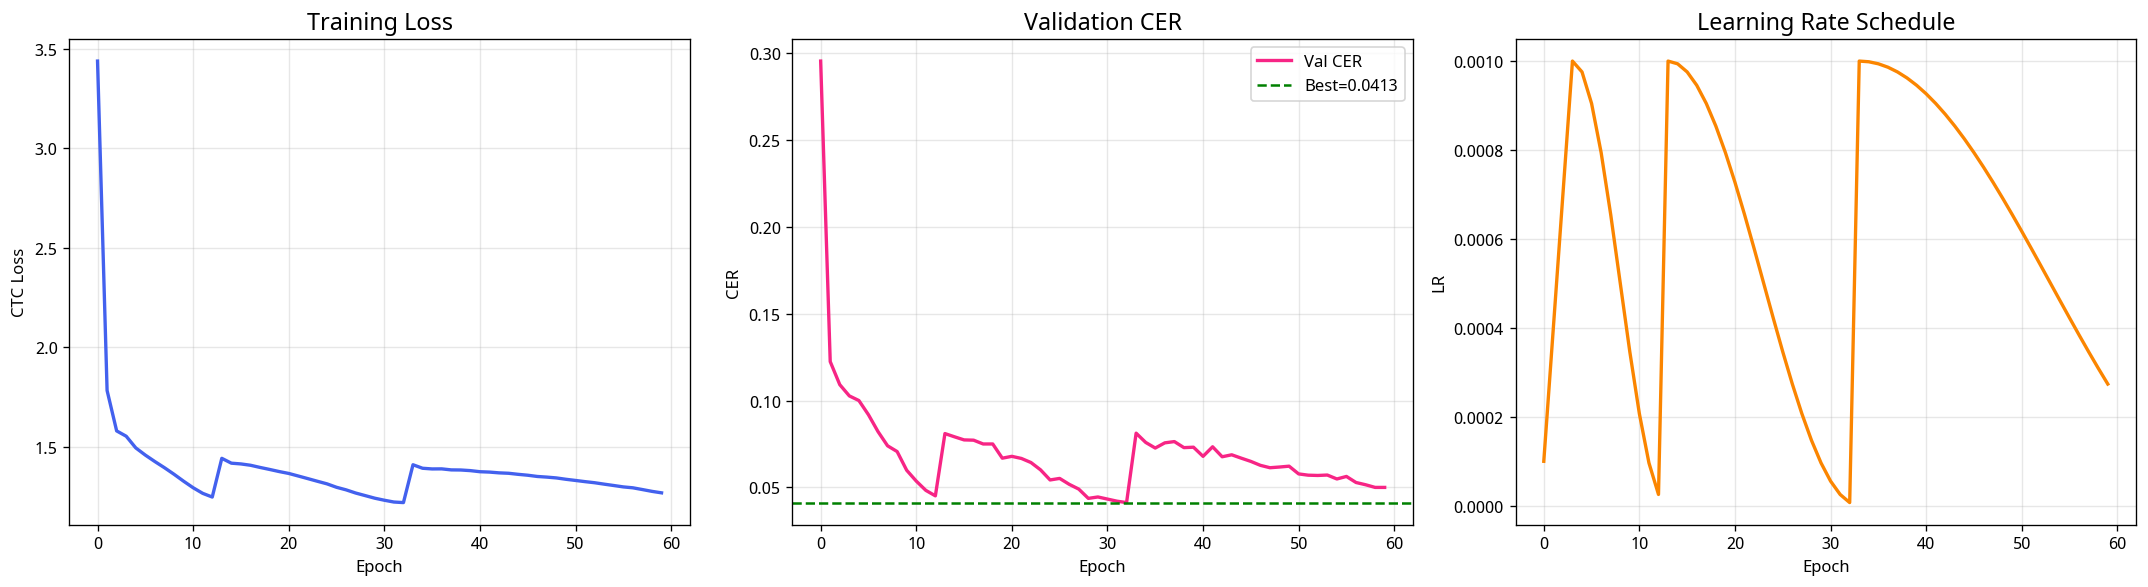

Saved: /kaggle/working/results/training_curves.png


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['loss'], color='#4361ee', lw=2)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CTC Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(history['val_cer'], color='#f72585', lw=2, label='Val CER')
axes[1].axhline(best_cer, color='green', ls='--', lw=1.5, label=f'Best={best_cer:.4f}')
axes[1].set_title('Validation CER', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('CER')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['lr'], color='#fb8500', lw=2)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS / 'training_curves.png'}")


## 17. Final Test Evaluation (Greedy + Beam Search)

We load the best checkpoint, then evaluate with:
- **Greedy** decoding (fast baseline)
- **Beam search** (beam_width=10, higher accuracy)


In [33]:
from concurrent.futures import ThreadPoolExecutor
import time as _time

# ── Fast beam search with top-k pruning ──
def beam_search_fast(log_probs_np, beam_width=10, blank=BLANK_IDX, top_k=20):
    """
    CTC prefix beam search with top-k class pruning.
    Only considers the top_k most likely characters at each timestep
    instead of all C classes. This gives ~7x speedup with negligible accuracy loss.
    """
    T, C = log_probs_np.shape
    beams = {(): (0.0, float('-inf'))}

    for t in range(T):
        new_beams = {}
        # TOP-K PRUNING: only consider the most likely classes
        top_indices = np.argpartition(log_probs_np[t], -top_k)[-top_k:]

        # Always include blank in candidates
        candidates = set(top_indices.tolist())
        candidates.add(blank)

        for prefix, (pb, pnb) in beams.items():
            p_total = np.logaddexp(pb, pnb)

            for c in candidates:
                p_c = log_probs_np[t, c]

                if c == blank:
                    key = prefix
                    new_pb = p_total + p_c
                    if key in new_beams:
                        old_pb, old_pnb = new_beams[key]
                        new_beams[key] = (np.logaddexp(old_pb, new_pb), old_pnb)
                    else:
                        new_beams[key] = (new_pb, float('-inf'))
                else:
                    if len(prefix) > 0 and prefix[-1] == c:
                        key = prefix
                        new_pnb = pnb + p_c
                        if key in new_beams:
                            o1, o2 = new_beams[key]
                            new_beams[key] = (o1, np.logaddexp(o2, new_pnb))
                        else:
                            new_beams[key] = (float('-inf'), new_pnb)

                        key2 = prefix + (c,)
                        new_pnb2 = pb + p_c
                        if key2 in new_beams:
                            o3, o4 = new_beams[key2]
                            new_beams[key2] = (o3, np.logaddexp(o4, new_pnb2))
                        else:
                            new_beams[key2] = (float('-inf'), new_pnb2)
                    else:
                        key = prefix + (c,)
                        new_pnb = p_total + p_c
                        if key in new_beams:
                            o5, o6 = new_beams[key]
                            new_beams[key] = (o5, np.logaddexp(o6, new_pnb))
                        else:
                            new_beams[key] = (float('-inf'), new_pnb)

        scored = {k: np.logaddexp(pb, pnb) for k, (pb, pnb) in new_beams.items()}
        top_keys = sorted(scored, key=scored.get, reverse=True)[:beam_width]
        beams = {k: new_beams[k] for k in top_keys}

    best = max(beams, key=lambda k: np.logaddexp(*beams[k]))
    return ''.join(idx_to_char.get(i, '') for i in best)


# ── Parallel batch beam search ──
def beam_batch_parallel(log_probs_tensor, beam_width=10, top_k=20, max_workers=4):
    """Decode a batch in parallel using ThreadPoolExecutor."""
    T, B, C = log_probs_tensor.shape
    # Move to CPU numpy ONCE for the whole batch
    all_np = log_probs_tensor.cpu().numpy()

    def _decode_one(i):
        return beam_search_fast(all_np[:, i, :], beam_width=beam_width, top_k=top_k)

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        results = list(pool.map(_decode_one, range(B)))
    return results


# ── Fast evaluation function ──
def evaluate_fast(model, loader, use_beam=False, beam_width=10, top_k=20):
    model.eval()
    total_ed, total_len, total_wer, count = 0, 0, 0.0, 0

    with torch.no_grad():
        for imgs, labels, label_lens in tqdm(loader, desc="Eval"):
            with torch.amp.autocast('cuda'):
                out = model(imgs.to(device))  # (T, B, C) — GPU forward

            if use_beam:
                preds = beam_batch_parallel(out, beam_width=beam_width, top_k=top_k)
            else:
                preds = greedy_decode_batch(out)

            offset = 0
            for i in range(imgs.size(0)):
                pred = preds[i]
                L = label_lens[i].item()
                gt = ''.join(idx_to_char.get(c, '') for c in labels[offset:offset + L].tolist())
                offset += L
                ed = editdistance.eval(pred, gt)
                total_ed += ed
                total_len += max(len(gt), 1)
                total_wer += (0.0 if pred == gt else 1.0)
                count += 1

    cer = total_ed / max(total_len, 1)
    wer = total_wer / max(count, 1)
    return cer, wer


# ═══════════════════════════════════════════════════════════════
# RUN EVALUATION
# ═══════════════════════════════════════════════════════════════

# Load best model
ckpt = torch.load(CKPT_DIR / 'best_model.pt', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded best model from epoch {ckpt['epoch']} (val CER={ckpt['val_cer']:.4f})")

# 1) Greedy — should take ~30-60 seconds
print("\n" + "=" * 60)
print("  GREEDY DECODING (fast)")
print("=" * 60)
t0 = _time.time()
test_cer_g, test_wer_g = evaluate_fast(model, test_loader, use_beam=False)
t_greedy = _time.time() - t0
print(f"Test CER (greedy) : {test_cer_g:.4f}")
print(f"Test WER (greedy) : {test_wer_g:.4f}")
print(f"Char accuracy     : {(1 - test_cer_g) * 100:.2f}%")
print(f"Word accuracy     : {(1 - test_wer_g) * 100:.2f}%")
print(f"Time              : {t_greedy:.1f}s")

# 2) Beam Search — should take ~3-5 min with top-k=20, beam=10
print("\n" + "=" * 60)
print("  BEAM SEARCH (width=10, top_k=20, parallel)")
print("=" * 60)
t0 = _time.time()
test_cer_b, test_wer_b = evaluate_fast(model, test_loader, use_beam=True, beam_width=10, top_k=20)
t_beam = _time.time() - t0
print(f"Test CER (beam)   : {test_cer_b:.4f}")
print(f"Test WER (beam)   : {test_wer_b:.4f}")
print(f"Char accuracy     : {(1 - test_cer_b) * 100:.2f}%")
print(f"Word accuracy     : {(1 - test_wer_b) * 100:.2f}%")
print(f"Time              : {t_beam:.1f}s")

# 3) Summary
print("\n" + "=" * 60)
print("  SUMMARY")
print("=" * 60)
print(f"Greedy  → CER: {test_cer_g:.4f} | WER: {test_wer_g:.4f} | {t_greedy:.0f}s")
print(f"Beam-10 → CER: {test_cer_b:.4f} | WER: {test_wer_b:.4f} | {t_beam:.0f}s")
improvement = (test_cer_g - test_cer_b) / test_cer_g * 100 if test_cer_g > 0 else 0
print(f"Beam improvement over greedy: {improvement:.1f}% CER reduction")

Loaded best model from epoch 33 (val CER=0.0413)

  GREEDY DECODING (fast)


Eval:   0%|          | 0/469 [00:00<?, ?it/s]

Test CER (greedy) : 0.0703
Test WER (greedy) : 0.1577
Char accuracy     : 92.97%
Word accuracy     : 84.23%
Time              : 68.3s

  BEAM SEARCH (width=10, top_k=20, parallel)


Eval:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a3e1f4209a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a3e1f4209a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Test CER (beam)   : 0.0696
Test WER (beam)   : 0.1561
Char accuracy     : 93.04%
Word accuracy     : 84.39%
Time              : 554.2s

  SUMMARY
Greedy  → CER: 0.0703 | WER: 0.1577 | 68s
Beam-10 → CER: 0.0696 | WER: 0.1561 | 554s
Beam improvement over greedy: 1.1% CER reduction


## 18. Test-Time Augmentation (TTA)

Apply `N` random augmentations to each test image and **average** the
log-probabilities before decoding. This smooths out noise-sensitive predictions.


In [34]:
def tta_predict_single(model, pil_img, n_aug=5):
    """Run TTA on one image: average log-probs over augmented versions."""
    steps   = preprocess_image(pil_img, return_steps=True)
    resized = steps["resized"]

    all_logprobs = []
    for _ in range(n_aug):
        aug_img = augment_image(resized)
        norm    = normalize_image(aug_img)
        tensor  = torch.FloatTensor(norm).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad(), torch.amp.autocast('cuda'):
            lp = model(tensor)                      # (T, 1, C)
        all_logprobs.append(lp[:, 0, :].cpu())      # (T, C)

    # Also include un-augmented
    norm0   = normalize_image(resized)
    tensor0 = torch.FloatTensor(norm0).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad(), torch.amp.autocast('cuda'):
        lp0 = model(tensor0)
    all_logprobs.append(lp0[:, 0, :].cpu())

    avg_lp = torch.logsumexp(torch.stack(all_logprobs), dim=0) - math.log(len(all_logprobs))
    return avg_lp  # (T, C)


def tta_evaluate(model, df, n_aug=5, max_samples=500, beam_width=10):
    """Evaluate TTA on a subset of the dataset."""
    model.eval()
    total_ed, total_len, total_wer, count = 0, 0, 0.0, 0

    indices = list(range(min(max_samples, len(df))))
    for idx in tqdm(indices, desc="TTA eval"):
        row  = df.iloc[idx]
        gt   = normalize_label(str(row[LABEL_COL]))
        try:
            pil_img = row_to_image(row)
        except Exception:
            continue

        avg_lp = tta_predict_single(model, pil_img, n_aug=n_aug)
        pred   = beam_search_decode(avg_lp, beam_width=beam_width)

        ed = editdistance.eval(pred, gt)
        total_ed  += ed
        total_len += max(len(gt), 1)
        total_wer += (0.0 if pred == gt else 1.0)
        count     += 1

    cer = total_ed / max(total_len, 1)
    wer = total_wer / max(count, 1)
    return cer, wer


# Run TTA on a subset (slow, so limit to 500 samples)
print("Running TTA evaluation (500 samples, 5 augmentations each) …")
tta_cer, tta_wer = tta_evaluate(model, test_df, n_aug=5, max_samples=500, beam_width=10)
print(f"\nTTA CER : {tta_cer:.4f}")
print(f"TTA WER : {tta_wer:.4f}")
print(f"Char accuracy (TTA) : {(1 - tta_cer) * 100:.2f}%")
print(f"Word accuracy (TTA) : {(1 - tta_wer) * 100:.2f}%")


Running TTA evaluation (500 samples, 5 augmentations each) …


TTA eval:   0%|          | 0/500 [00:00<?, ?it/s]


TTA CER : 0.0536
TTA WER : 0.1560
Char accuracy (TTA) : 94.64%
Word accuracy (TTA) : 84.40%


## 19. Sample Predictions (Visual Comparison)

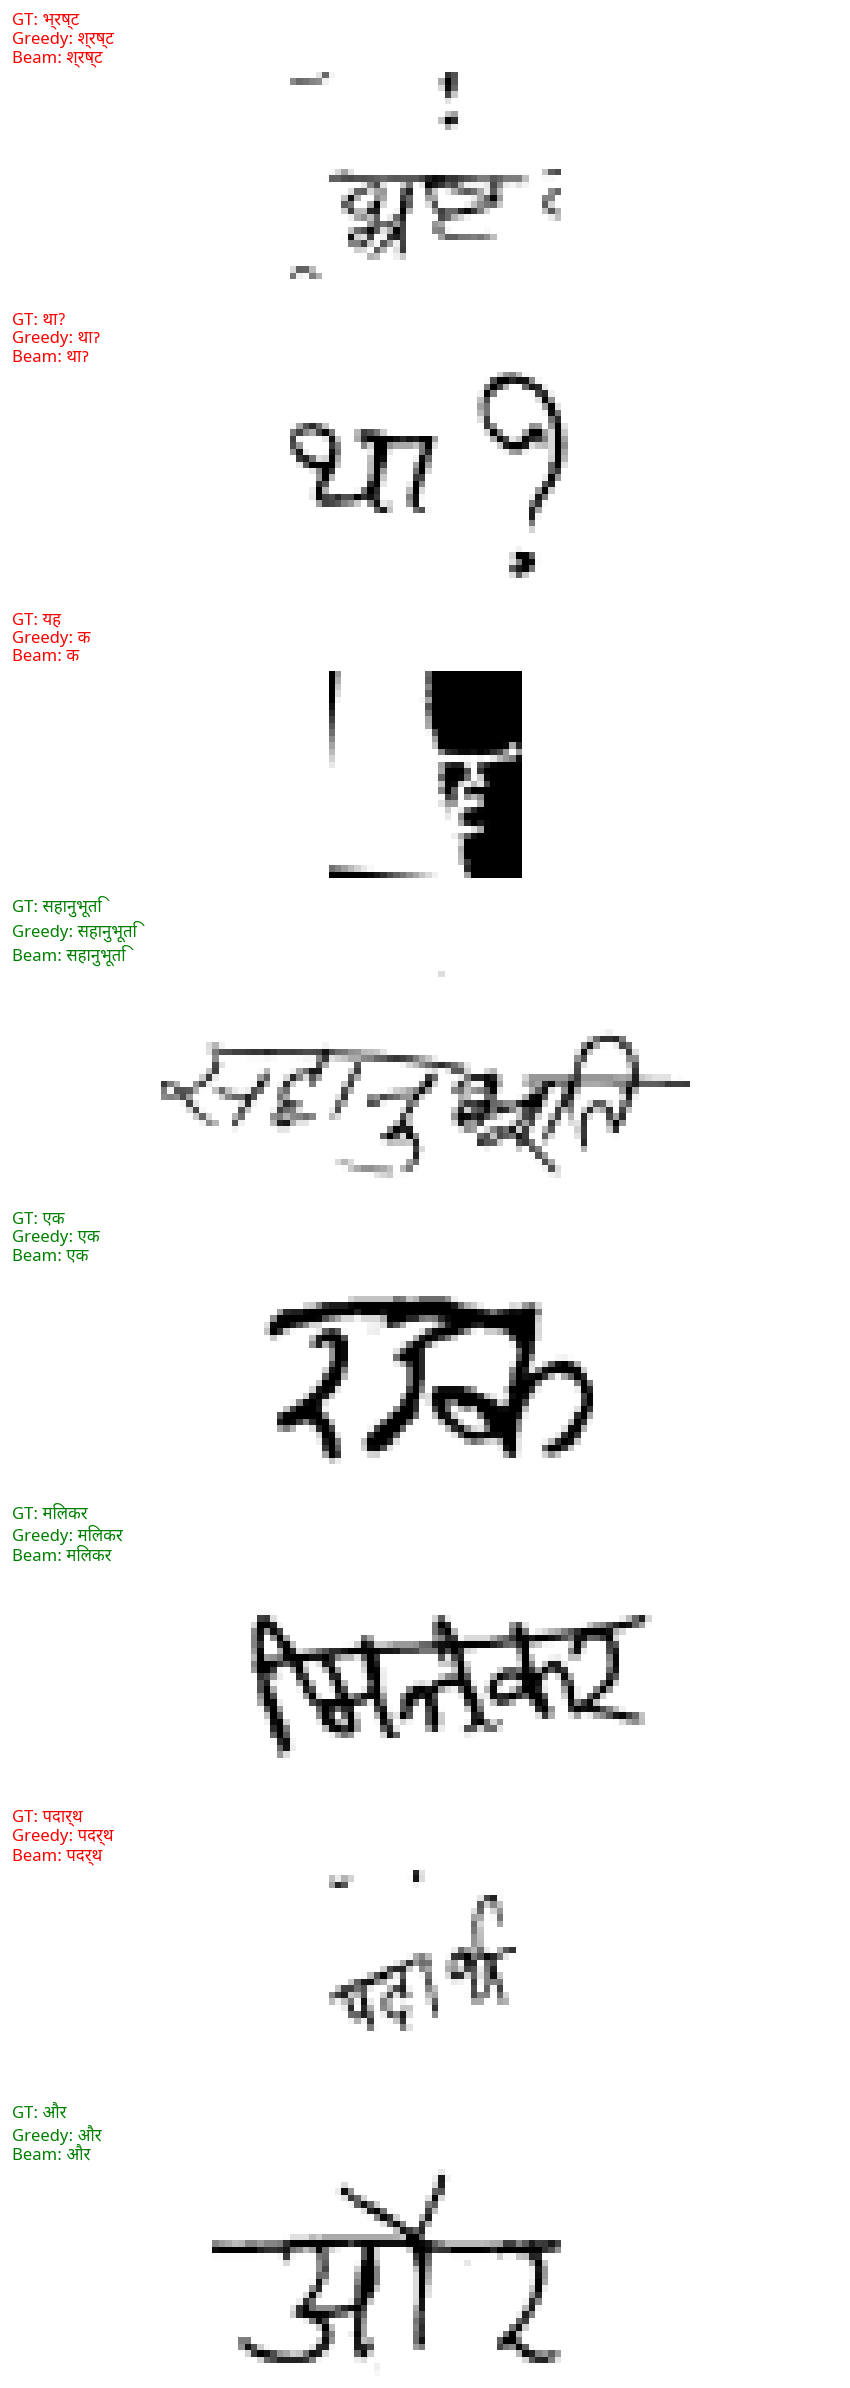

In [35]:
def show_predictions(model, df, n=8, use_beam=True, beam_width=10):
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n))
    if n == 1:
        axes = [axes]

    model.eval()
    indices = random.sample(range(len(df)), n)

    for ax, idx in zip(axes, indices):
        row = df.iloc[idx]
        gt  = normalize_label(str(row[LABEL_COL]))
        try:
            pil_img = row_to_image(row)
        except Exception:
            continue

        steps = preprocess_image(pil_img, return_steps=True)
        norm  = normalize_image(steps["resized"])
        tensor = torch.FloatTensor(norm).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad(), torch.amp.autocast('cuda'):
            out = model(tensor)

        pred_greedy = greedy_decode(out[:, 0, :])
        pred_beam   = beam_search_decode(out[:, 0, :], beam_width=beam_width) if use_beam else ""

        ax.imshow(steps["resized"], cmap='gray')
        ax.axis('off')
        color = 'green' if pred_beam == gt else 'red'
        ax.set_title(
            f'GT: {gt}\nGreedy: {pred_greedy}\nBeam: {pred_beam}',
            fontsize=12, fontproperties=DEVA_FONT, color=color, loc='left'
        )

    plt.tight_layout()
    plt.savefig(RESULTS / 'sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(model, test_df, n=8, use_beam=True)


## 20. Error Analysis

In [36]:
def error_analysis(model, loader, max_batches=20):
    """Collect per-character and per-length error statistics."""
    model.eval()
    char_errors  = Counter()  # idx → total errors involving this char
    char_totals  = Counter()  # idx → total occurrences
    len_errors   = {}         # gt_len → list of CER values

    with torch.no_grad():
        for bi, (imgs, labels, label_lens) in enumerate(loader):
            if bi >= max_batches:
                break
            out = model(imgs.to(device))
            preds = greedy_decode_batch(out)

            offset = 0
            for i in range(imgs.size(0)):
                pred = preds[i]
                L    = label_lens[i].item()
                gt   = ''.join(idx_to_char.get(c, '') for c in labels[offset:offset + L].tolist())
                offset += L

                ed  = editdistance.eval(pred, gt)
                cer = ed / max(len(gt), 1)

                ln = len(gt)
                len_errors.setdefault(ln, []).append(cer)

                for ch in gt:
                    idx = char_to_idx.get(ch, UNK_IDX)
                    char_totals[idx] += 1
                    if ch not in pred:
                        char_errors[idx] += 1

    # Top-20 most-confused characters
    print("\n─── Top 20 Highest Error-Rate Characters ───")
    err_rates = {}
    for idx in char_totals:
        if char_totals[idx] >= 10:
            err_rates[idx] = char_errors[idx] / char_totals[idx]

    sorted_errs = sorted(err_rates.items(), key=lambda x: x[1], reverse=True)[:20]
    print(f"{'Char':<10} {'Idx':<6} {'Errors':<10} {'Total':<10} {'Error Rate':<10}")
    print("-" * 50)
    for idx, rate in sorted_errs:
        ch = idx_to_char.get(idx, '?')
        display = ch if ch not in ('<BLANK>', '<UNK>', '<PAD>') else f'[{ch}]'
        print(f"{display:<10} {idx:<6} {char_errors[idx]:<10} {char_totals[idx]:<10} {rate:.4f}")

    # CER by word length
    print("\n─── CER by Word Length ───")
    print(f"{'Length':<10} {'Count':<10} {'Mean CER':<10}")
    print("-" * 35)
    for ln in sorted(len_errors.keys()):
        vals = len_errors[ln]
        if len(vals) >= 5:
            print(f"{ln:<10} {len(vals):<10} {np.mean(vals):.4f}")

error_analysis(model, test_loader, max_batches=20)



─── Top 20 Highest Error-Rate Characters ───
Char       Idx    Errors     Total      Error Rate
--------------------------------------------------
़          95     4          15         0.2667
ु          100    10         61         0.1639
थ          74     5          33         0.1515
ष          92     3          22         0.1364
छ          64     2          15         0.1333
ू          101    3          23         0.1304
श          91     4          33         0.1212
उ          48     3          32         0.0938
भ          82     4          43         0.0930
ं          42     14         171        0.0819
ध          76     2          26         0.0769
ो          110    7          127        0.0551
अ          44     2          37         0.0541
्          112    10         190        0.0526
ज          65     4          77         0.0519
ण          72     1          20         0.0500
य          84     6          126        0.0476
ग          60     3          65         0.0462
प     

## 21. Save Final Artifacts

In [37]:
# Save training history
with open(RESULTS / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

# Summary
print("=" * 70)
print("PHASE 3 (IMPROVED) — FINAL RESULTS")
print("=" * 70)
print(f"Architecture    : ResNet-SE + BiLSTM({NUM_LSTM_LAYERS}×{HIDDEN_SIZE}) + CTC")
print(f"Parameters      : {sum(p.numel() for p in model.parameters()):,}")
print(f"Dataset         : 200k (train {len(train_df):,} / val {len(val_df):,} / test {len(test_df):,})")
print(f"Best val CER    : {best_cer:.4f}")
print(f"Test CER (grdy) : {test_cer_g:.4f}")
print(f"Test WER (grdy) : {test_wer_g:.4f}")
print(f"Test CER (beam) : {test_cer_b:.4f}")
print(f"Test WER (beam) : {test_wer_b:.4f}")
print(f"TTA CER (500)   : {tta_cer:.4f}")
print(f"TTA WER (500)   : {tta_wer:.4f}")
print("=" * 70)
print(f"Checkpoint : {CKPT_DIR / 'best_model.pt'}")
print(f"Curves     : {RESULTS / 'training_curves.png'}")
print(f"History    : {RESULTS / 'training_history.json'}")


PHASE 3 (IMPROVED) — FINAL RESULTS
Architecture    : ResNet-SE + BiLSTM(3×512) + CTC
Parameters      : 22,410,571
Dataset         : 200k (train 150,000 / val 20,000 / test 30,000)
Best val CER    : 0.0413
Test CER (grdy) : 0.0703
Test WER (grdy) : 0.1577
Test CER (beam) : 0.0696
Test WER (beam) : 0.1561
TTA CER (500)   : 0.0536
TTA WER (500)   : 0.1560
Checkpoint : /kaggle/working/checkpoints/best_model.pt
Curves     : /kaggle/working/results/training_curves.png
History    : /kaggle/working/results/training_history.json


In [41]:
# Force download best_model.pt from Kaggle notebook
from IPython.display import FileLink
import shutil, os

# Copy checkpoint to /kaggle/working/ (which is accessible for download)
src = '/kaggle/working/checkpoints/best_model.pt'
dst = '/kaggle/working/best_model.pt'

if os.path.exists(src):
    shutil.copy2(src, dst)
    print(f"Model copied to {dst}")
    print(f"Size: {os.path.getsize(dst) / 1e6:.1f} MB")
    display(FileLink('best_model.pt', result_html_prefix="Click to download: "))
else:
    print(f"ERROR: {src} not found. Train the model first.")


Model copied to /kaggle/working/best_model.pt
Size: 269.1 MB


/kaggle/working/best_model.pt